In [ ]:
import os
import glob
import json
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import cv2
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import torchvision.transforms as transforms
from torchvision import models

import timm

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc,
    f1_score,
    accuracy_score
)

import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 4
HAIR_REMOVAL = True

OUTPUT_DIR = "/kaggle/working"
os.makedirs(OUTPUT_DIR, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans"
})

sns.set_style("whitegrid")

Using device: cuda
GPU: Tesla T4


In [ ]:
DATA_DIR = "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000"

META_PATH = os.path.join(DATA_DIR, "HAM10000_metadata.csv")
search_folders = [
    os.path.join(DATA_DIR, "HAM10000_images_part_1"),
    os.path.join(DATA_DIR, "HAM10000_images_part_2")
]
df = pd.read_csv(META_PATH)

image_path_lookup = {}

for folder in search_folders:
    for filepath in glob.glob(os.path.join(folder, "*.jpg")):
        image_id = os.path.splitext(os.path.basename(filepath))[0]
        image_path_lookup[image_id] = filepath

df["image_path"] = df["image_id"].map(image_path_lookup)
df = df.dropna(subset=["image_path"]).reset_index(drop=True)

le = LabelEncoder()
df["label"] = le.fit_transform(df["dx"])

CLASS_NAMES = list(le.classes_)
NUM_CLASSES = len(CLASS_NAMES)
LABEL_MAP = {cls_name: idx for idx, cls_name in enumerate(CLASS_NAMES)}
location_dummies = pd.get_dummies(df["localization"], prefix="loc")
LOCATION_COLS = list(location_dummies.columns)
df = pd.concat([df, location_dummies], axis=1)

META_FEATURES = LOCATION_COLS
META_DIM = len(META_FEATURES)

print("Total images:", len(df))
print("Classes:", CLASS_NAMES)

print("\nClass distribution:")
print(df["dx"].value_counts())


Total images: 10015
Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

Class distribution:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


In [ ]:
def remove_hair_rgb(image_rgb):
    gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (17, 17))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)

    _, mask = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)

    image_bgr = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR)
    inpainted_bgr = cv2.inpaint(image_bgr, mask, 1, cv2.INPAINT_TELEA)

    inpainted_rgb = cv2.cvtColor(inpainted_bgr, cv2.COLOR_BGR2RGB)

    return inpainted_rgb

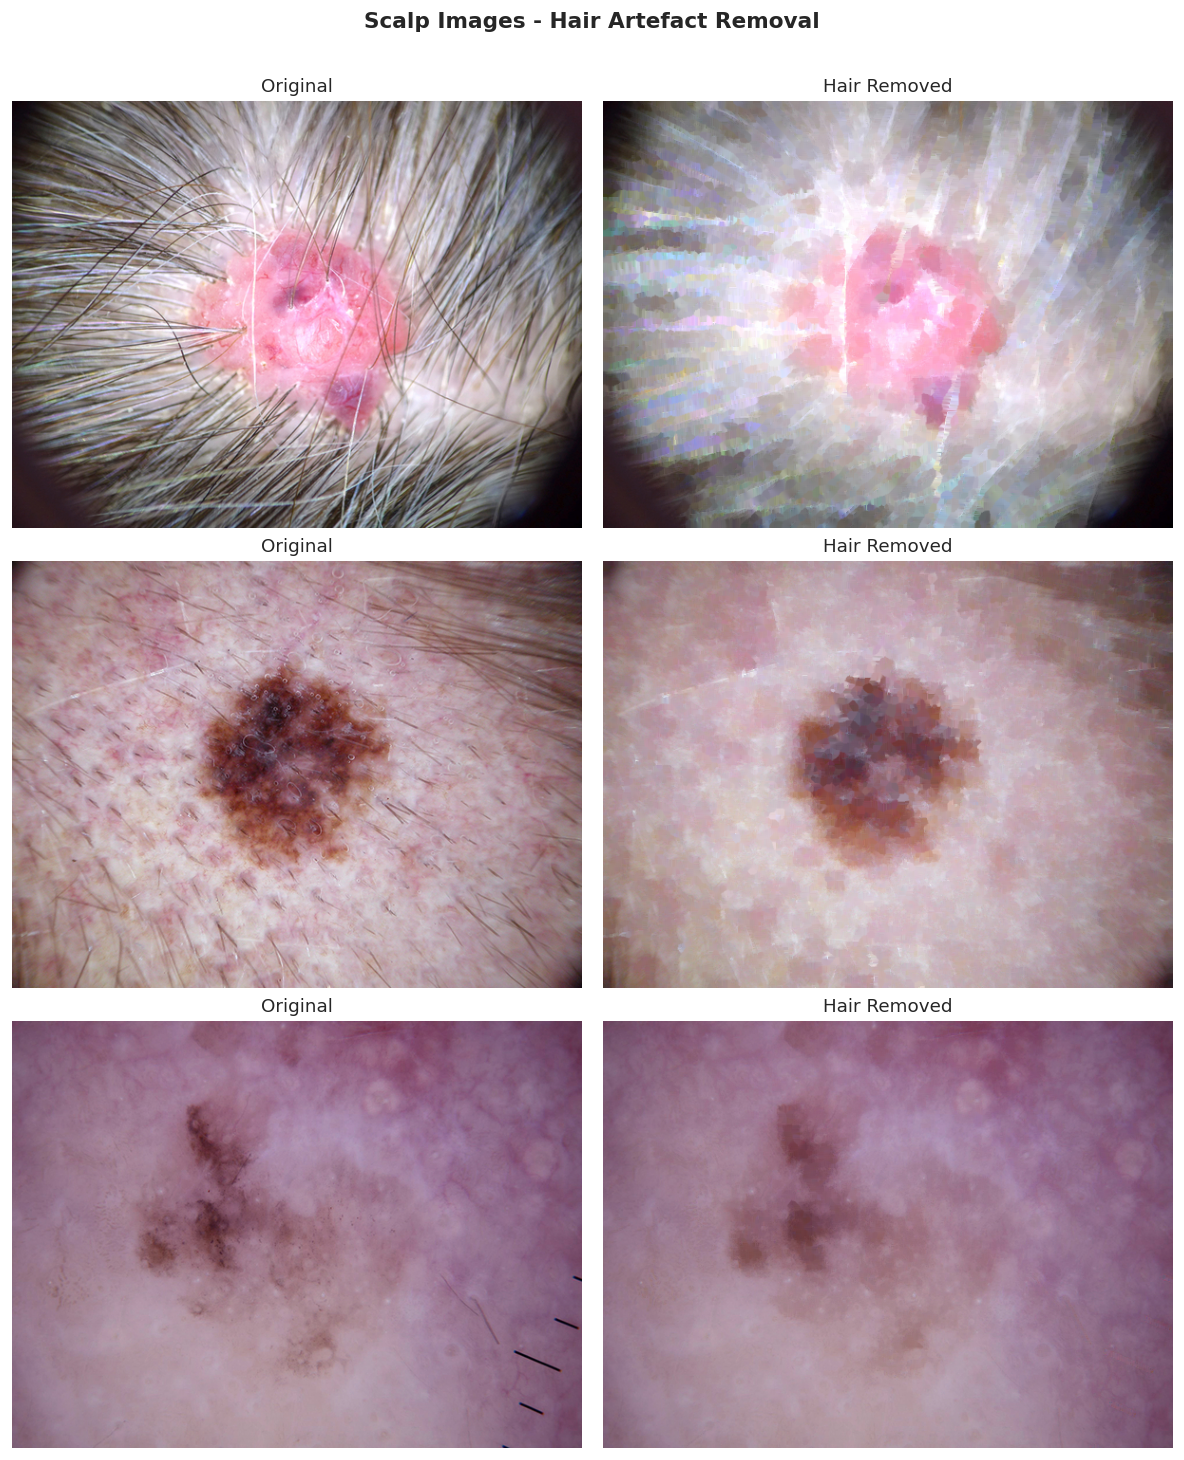

In [ ]:
scalp_df = df[df["localization"].str.lower() == "scalp"].reset_index(drop=True)

sample_paths = scalp_df["image_path"].sample(
    min(3, len(scalp_df)),
    random_state=SEED
).tolist()

fig, axes = plt.subplots(
    len(sample_paths),
    2,
    figsize=(10, 4 * len(sample_paths))
)

if len(sample_paths) == 1:
    axes = np.expand_dims(axes, axis=0)

for i, path in enumerate(sample_paths):
    orig_bgr = cv2.imread(path)

    if orig_bgr is None:
        print(f"Could not read image: {path}")
        continue

    orig_rgb = cv2.cvtColor(orig_bgr, cv2.COLOR_BGR2RGB)

    cleaned_rgb = remove_hair_rgb(orig_rgb)

    axes[i, 0].imshow(orig_rgb)
    axes[i, 0].set_title("Original", fontsize=11)
    axes[i, 0].axis("off")

    axes[i, 1].imshow(cleaned_rgb)
    axes[i, 1].set_title("Hair Removed", fontsize=11)
    axes[i, 1].axis("off")

plt.suptitle(
    "Scalp Images - Hair Artefact Removal",
    fontsize=13,
    fontweight="bold",
    y=1.01
)

plt.tight_layout()
plt.show()

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(30),
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.2,
        hue=0.1
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
groups = df["lesion_id"]
y = df["label"]

best_split = None
best_score = float("inf")

sgkf_test = StratifiedGroupKFold(
    n_splits=10,
    shuffle=True,
    random_state=SEED
)

for train_val_idx, test_idx in sgkf_test.split(df, y, groups):
    train_val_df_temp = df.iloc[train_val_idx].reset_index(drop=True)
    test_df_temp = df.iloc[test_idx].reset_index(drop=True)

    test_pct = len(test_df_temp) / len(df) * 100

    sgkf_val = StratifiedGroupKFold(
        n_splits=9,
        shuffle=True,
        random_state=SEED
    )

    for train_idx, val_idx in sgkf_val.split(
        train_val_df_temp,
        train_val_df_temp["label"],
        train_val_df_temp["lesion_id"]
    ):
        train_df_temp = train_val_df_temp.iloc[train_idx].reset_index(drop=True)
        val_df_temp = train_val_df_temp.iloc[val_idx].reset_index(drop=True)

        train_pct = len(train_df_temp) / len(df) * 100
        val_pct = len(val_df_temp) / len(df) * 100

        test_ok = test_pct >= 10.0
        val_ok = val_pct >= 10.0

        if test_ok and val_ok:
            score = abs(test_pct - 10.0) + abs(val_pct - 10.0)

            if score < best_score:
                best_score = score
                best_split = (
                    train_df_temp.copy(),
                    val_df_temp.copy(),
                    test_df_temp.copy(),
                    train_pct,
                    val_pct,
                    test_pct
                )
train_df, val_df, test_df, train_pct, val_pct, test_pct = best_split

print("Split sizes:")
print("Train:", len(train_df), f"({train_pct:.2f}%)")
print("Validation:", len(val_df), f"({val_pct:.2f}%)")
print("Test:", len(test_df), f"({test_pct:.2f}%)")

Split sizes:
Train: 8003 (79.91%)
Validation: 1004 (10.02%)
Test: 1008 (10.06%)


In [ ]:
class HAMLocationDataset(Dataset):
    def __init__(self, dataframe, transform=None, apply_hair_removal=True, meta_features=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.apply_hair_removal = apply_hair_removal
        self.meta_features = meta_features

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image_path = row["image_path"]
        label = int(row["label"])

        image_bgr = cv2.imread(image_path)

        if image_bgr is None:
            raise FileNotFoundError(f"Image not found: {image_path}")

        image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

        if self.apply_hair_removal:
            image_rgb = remove_hair_rgb(image_rgb)

        image_pil = Image.fromarray(image_rgb)

        if self.transform:
            image_tensor = self.transform(image_pil)
        else:
            image_tensor = transforms.ToTensor()(image_pil)

        metadata = row[self.meta_features].values.astype(np.float32)
        metadata = torch.tensor(metadata, dtype=torch.float32)

        label = torch.tensor(label, dtype=torch.long)

        return image_tensor, metadata, label


In [ ]:
class_counts = train_df["label"].value_counts().sort_index().values

class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * NUM_CLASSES

CLASS_WEIGHTS = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(DEVICE)

sample_weights = train_df["label"].map(
    {i: class_weights[i] for i in range(NUM_CLASSES)}
).values

sample_weights = torch.tensor(
    sample_weights,
    dtype=torch.double
)

train_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

print("Class weights:")
for cls_name, weight in zip(CLASS_NAMES, CLASS_WEIGHTS.cpu().numpy()):
    print(f"{cls_name}: {weight:.4f}")


class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        ce_loss = nn.functional.cross_entropy(
            logits,
            targets,
            weight=self.alpha,
            reduction="none"
        )

        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        if self.reduction == "mean":
            return focal_loss.mean()
        elif self.reduction == "sum":
            return focal_loss.sum()
        else:
            return focal_loss


CRITERION = nn.CrossEntropyLoss()

Class weights:
akiec: 0.8810
bcc: 0.5902
bkl: 0.2689
df: 2.7863
mel: 0.2701
nv: 0.0448
vasc: 2.1587


In [ ]:
train_dataset = HAMLocationDataset(
    train_df,
    transform=train_transform,
    apply_hair_removal=HAIR_REMOVAL,
    meta_features=META_FEATURES
)

val_dataset = HAMLocationDataset(
    val_df,
    transform=val_test_transform,
    apply_hair_removal=HAIR_REMOVAL,
    meta_features=META_FEATURES
)

test_dataset = HAMLocationDataset(
    test_df,
    transform=val_test_transform,
    apply_hair_removal=HAIR_REMOVAL,
    meta_features=META_FEATURES
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

images, metadata, labels = next(iter(train_loader))

print("Image batch shape    :", images.shape)
print("Metadata batch shape :", metadata.shape)
print("Label batch shape    :", labels.shape)

Image batch shape    : torch.Size([32, 3, 224, 224])
Metadata batch shape : torch.Size([32, 15])
Label batch shape    : torch.Size([32])


In [ ]:
class ViTLocationClassifier(nn.Module):
    def __init__(self, backbone, image_feature_dim, meta_dim, num_classes):
        super().__init__()

        self.backbone = backbone

        self.meta_net = nn.Sequential(
            nn.Linear(meta_dim, 32),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.2)
        )

        self.head = nn.Sequential(
            nn.LayerNorm(image_feature_dim + 32),
            nn.Dropout(p=0.4),

            nn.Linear(image_feature_dim + 32, 256),
            nn.GELU(),
            nn.Dropout(p=0.3),

            nn.Linear(256, num_classes)
        )

    def forward(self, image, metadata):
        image_features = self.backbone(image)
        meta_features = self.meta_net(metadata)

        combined_features = torch.cat(
            [image_features, meta_features],
            dim=1
        )

        logits = self.head(combined_features)
        return logits


def build_vit_location(num_classes, meta_dim, pretrained=True):
    backbone = timm.create_model(
        "vit_base_patch16_224",
        pretrained=pretrained,
        num_classes=0
    )

    image_feature_dim = backbone.num_features

    model = ViTLocationClassifier(
        backbone=backbone,
        image_feature_dim=image_feature_dim,
        meta_dim=meta_dim,
        num_classes=num_classes
    )

    return model

In [ ]:
class EarlyStopping:
    def __init__(self, patience=7, min_delta=1e-4, mode="max"):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.counter = 0
        self.best_score = None
        self.early_stop = False

    def __call__(self, current_score):
        if self.best_score is None:
            self.best_score = current_score
            return False

        if self.mode == "max":
            improved = current_score > self.best_score + self.min_delta
        else:
            improved = current_score < self.best_score - self.min_delta

        if improved:
            self.best_score = current_score
            self.counter = 0
        else:
            self.counter += 1

        if self.counter >= self.patience:
            self.early_stop = True

        return self.early_stop


def train_one_epoch(model, loader, optimiser, criterion, device):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for images, metadata, labels in loader:
        images = images.to(device)
        metadata = metadata.to(device)
        labels = labels.to(device)

        optimiser.zero_grad()

        logits = model(images, metadata)
        loss = criterion(logits, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimiser.step()

        preds = logits.argmax(dim=1)

        total_loss += loss.item() * images.size(0)
        total_correct += (preds == labels).sum().item()
        total_samples += images.size(0)

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples

    return avg_loss, avg_acc


@torch.no_grad()
def evaluate(model, loader, criterion, device, num_classes):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    all_probs = []
    all_preds = []
    all_labels = []

    for images, metadata, labels in loader:
        images = images.to(device)
        metadata = metadata.to(device)
        labels = labels.to(device)

        logits = model(images, metadata)
        loss = criterion(logits, labels)

        probs = torch.softmax(logits, dim=1)
        preds = probs.argmax(dim=1)

        total_loss += loss.item() * images.size(0)
        total_correct += (preds == labels).sum().item()
        total_samples += images.size(0)

        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples

    all_probs = np.concatenate(all_probs, axis=0)
    all_preds = np.concatenate(all_preds, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    labels_bin = label_binarize(
        all_labels,
        classes=list(range(num_classes))
    )

    try:
        macro_auc = roc_auc_score(
            labels_bin,
            all_probs,
            multi_class="ovr",
            average="macro"
        )
    except ValueError:
        macro_auc = 0.0

    return avg_loss, avg_acc, macro_auc, all_probs, all_preds, all_labels

In [ ]:
def train_model(
    model,
    model_name,
    train_loader,
    val_loader,
    criterion,
    device,
    num_classes,
    num_epochs=30,
    lr=1e-5,
    weight_decay=1e-4,
    unfreeze_epoch=0,
    patience=7
):

    for param in model.parameters():
        param.requires_grad = True

    optimizer = optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=3
    )

    early_stopper = EarlyStopping(
        patience=patience,
        min_delta=1e-4,
        mode="max"
    )

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "val_auc": []
    }

    best_auc = -np.inf
    best_state = None

    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch(
            model=model,
            loader=train_loader,
            optimiser=optimizer,
            criterion=criterion,
            device=device
        )

        val_loss, val_acc, val_auc, _, _, _ = evaluate(
            model=model,
            loader=val_loader,
            criterion=criterion,
            device=device,
            num_classes=num_classes
        )

        scheduler.step(val_auc)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_auc"].append(val_auc)

        print(
            f"Epoch [{epoch + 1}/{num_epochs}] "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc * 100:.2f}% | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc * 100:.2f}% | "
            f"Val AUC: {val_auc:.4f}"
        )

        if val_auc > best_auc:
            best_auc = val_auc
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }

            save_path = os.path.join(OUTPUT_DIR, f"best_{model_name}.pth")
            torch.save(model.state_dict(), save_path)
            print(f"Best model saved: {save_path}")

        if early_stopper(val_auc):
            print("Early stopping triggered.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
        model.to(device)
        print(f"Best {model_name} loaded. Best Val AUC: {best_auc:.4f}")

    return history

In [ ]:
print("ViT-B/16 Model")

vit_model = build_vit_location(
    num_classes=NUM_CLASSES,
    meta_dim=META_DIM,
    pretrained=True
).to(DEVICE)

vit_history = train_model(
    model=vit_model,
    model_name="ViT_B16_Location",
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=CRITERION,
    device=DEVICE,
    num_classes=NUM_CLASSES,
    num_epochs=30,
    lr=5e-6,
    weight_decay=1e-4,
    unfreeze_epoch=0,
    patience=5
)

ViT-B/16 Model


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Epoch [1/30] Train Loss: 0.9720 | Train Acc: 68.54% | Val Loss: 0.7697 | Val Acc: 72.11% | Val AUC: 0.8714
Best model saved: /kaggle/working/best_ViT_B16_Location.pth
Epoch [2/30] Train Loss: 0.7503 | Train Acc: 74.11% | Val Loss: 0.6350 | Val Acc: 76.99% | Val AUC: 0.9283
Best model saved: /kaggle/working/best_ViT_B16_Location.pth
Epoch [3/30] Train Loss: 0.6533 | Train Acc: 77.32% | Val Loss: 0.5841 | Val Acc: 79.58% | Val AUC: 0.9509
Best model saved: /kaggle/working/best_ViT_B16_Location.pth
Epoch [4/30] Train Loss: 0.5888 | Train Acc: 79.51% | Val Loss: 0.5164 | Val Acc: 82.57% | Val AUC: 0.9557
Best model saved: /kaggle/working/best_ViT_B16_Location.pth
Epoch [5/30] Train Loss: 0.5490 | Train Acc: 80.92% | Val Loss: 0.4580 | Val Acc: 84.16% | Val AUC: 0.9660
Best model saved: /kaggle/working/best_ViT_B16_Location.pth
Epoch [6/30] Train Loss: 0.5019 | Train Acc: 82.26% | Val Loss: 0.5012 | Val Acc: 83.37% | Val AUC: 0.9636
Epoch [7/30] Train Loss: 0.4764 | Train Acc: 83.27% | Val 

Classification Report:
              precision    recall  f1-score   support

       akiec     0.5000    0.8077    0.6176        26
         bcc     0.7381    0.7561    0.7470        41
         bkl     0.8108    0.5263    0.6383       114
          df     0.9000    0.4286    0.5806        21
         mel     0.7015    0.4653    0.5595       101
          nv     0.8830    0.9725    0.9256       691
        vasc     1.0000    0.8571    0.9231        14

    accuracy                         0.8452      1008
   macro avg     0.7905    0.6877    0.7131      1008
weighted avg     0.8429    0.8452    0.8340      1008



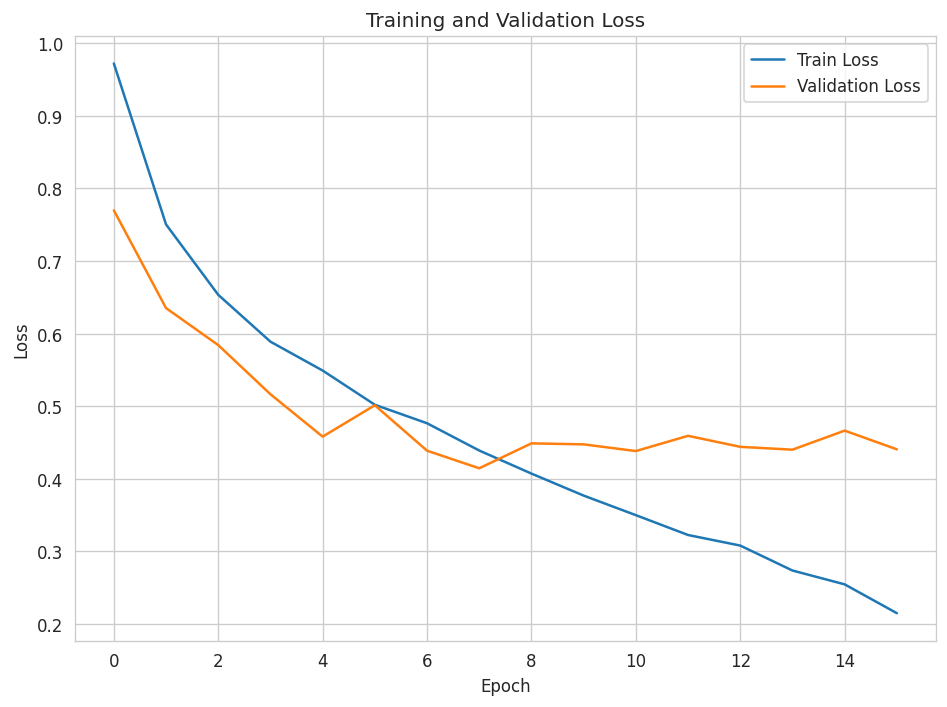

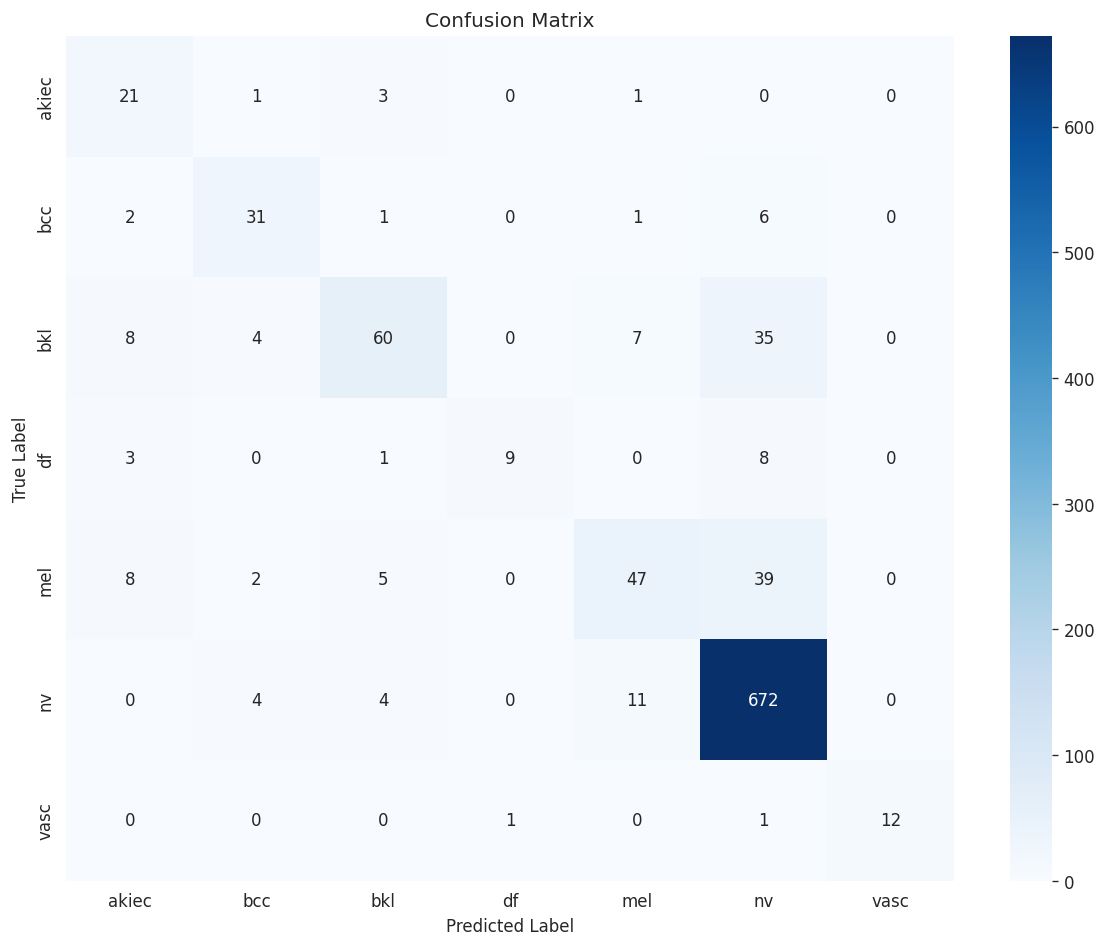

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

test_loss, test_acc, _, test_probs, test_preds, test_labels = evaluate(
    vit_model,
    test_loader,
    CRITERION,
    DEVICE,
    NUM_CLASSES
)

print("Classification Report:")
print(
    classification_report(
        test_labels,
        test_preds,
        target_names=CLASS_NAMES,
        digits=4
    )
)

plt.figure(figsize=(8, 6))

plt.plot(vit_history["train_loss"], label="Train Loss")
plt.plot(vit_history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()